In [1]:
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import llhd_loss, adc2charge, mse_adc
from optimize.strategies import LUTSimulation, LUTProbabilisticSimulation, ProbabilisticLossStrategy, CollapsedProbabilisticLossStrategy, GenericLossStrategy
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

/sdf/group/neutrino/pgranger/larnd-sim-jax


/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# --- Configuration ---

INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_proton_edep_2cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44.npy'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

# Parameters to optimize (and their ranges)

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

# Simulation Settings
ELECTRON_SAMPLING_RESOLUTION = 0.01
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 400

In [3]:
# --- Setup Parameters ---

ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH,
    # Ensure noise params are zero for deterministic checks if needed, but llhd handles noise in prob
)

response, ref_params = load_lut(LUT_FILE, ref_params)

# Set nominal values
initial_values = {p: ranges[p]['nom'] for p in RELEVANT_PARAMS}
current_params = ref_params.replace(**initial_values)

print("Parameters initialized.")

INFO:larndsim.consts_jax:Loading response from numpy array
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Parameters initialized.


In [16]:
!nvidia-smi

Thu Feb  5 06:13:53 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.07             Driver Version: 535.161.07   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  | 00000000:41:00.0 Off |                    0 |
| N/A   37C    P0              59W / 400W |   9020MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [4]:
# --- Initialize Strategies ---

# 1. Stochastic Strategy for Generating Target (Ground Truth)
target_strategy = LUTSimulation(response)

# 2. Probabilistic Strategy for Prediction (Differentiable)
pred_strategy = LUTSimulation(response)

# 3. Loss Strategy - now computes proper negative log-likelihood
# No need to pass llhd_loss, the strategy implements it internally
# loss_strategy = ProbabilisticLossStrategy(sigma_charge=500.0)
loss_strategy = GenericLossStrategy(
    loss_fn=mse_adc
)

print("Strategies initialized.")
print("Loss: Negative log-likelihood with Gaussian charge prior (sigma=500 electrons)")

Strategies initialized.
Loss: Negative log-likelihood with Gaussian charge prior (sigma=500 electrons)


In [5]:
# --- Load Data ---

dataset = TracksDataset(filename=INPUT_FILE, ntrack=-1, max_nbatch=1, print_input=True, max_batch_len=1000,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=100)

# Get one batch
tracks_batch = dataloader[0]
track_fields = dataset.get_track_fields()

# Prepare tracks for JAX
tracks = jax.device_put(tracks_batch.reshape(-1, len(track_fields)))

print(f"Loaded {tracks.shape[0]} tracks segments.")

INFO:optimize.dataio:training set [ev, trk]: [(    0, 0) (    0, 2) (    0, 3) ... (99999, 7) (99999, 8) (99999, 9)]
INFO:optimize.dataio:-- The used data includes a total track length of 998.4634399414062 cm.
INFO:optimize.dataio:-- The maximum batch track length is 1000 cm.
INFO:optimize.dataio:-- The number of batches is 1.
INFO:optimize.dataio:Padding sequences with padding value: 0


Loaded 101143 tracks segments.


In [7]:
len(dataloader)

1

In [6]:
# --- Generate Target (Data) ---

rngkey = 42

# Run stochastic simulation to get 'fake data'

target_output = target_strategy.predict(current_params, tracks, track_fields, rngkey)

print("Target generated.")
print(f"Number of hits in target: {target_output['adcs'].shape[0]}")
target_output['pixel_id'] = target_output['unique_pixels']

Target generated.
Number of hits in target: 9108


In [7]:
# Define parameter to scan (use eField as before)
param_to_scan_test = 'signal_length'
signal_length_nominal_test = current_params.signal_length

# Create scan range: wider range to see behavior
scan_values_test = np.arange(100, 400, 10)

# Storage for results
results_test = {
    'scan_values': scan_values_test,
    'loss': []
}

# Perform scan
for i, param_val in enumerate(tqdm(scan_values_test)):
    local_params = current_params.replace(**{param_to_scan_test: param_val})
    prediction = pred_strategy.predict(local_params, tracks, track_fields, rngkey)
    loss_value, _ = loss_strategy.compute(local_params, prediction, target_output)
    results_test['loss'].append(float(loss_value))


  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [03:46<00:00,  7.55s/it]


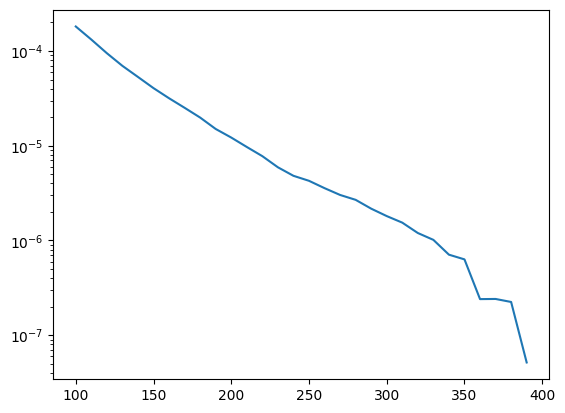

In [8]:
plt.plot(results_test['scan_values'], results_test['loss'])
plt.yscale('log')

## Detailed Analysis: Hit Time and Charge Variations

Now let's examine how hit times (ticks) and charges vary across different signal_length values.

In [9]:
# Select a few representative signal_length values for detailed comparison
signal_lengths_to_compare = [100, 150, 200, 250, 300, 350, 400]

# Storage for detailed results
detailed_results = {}

print("Running detailed simulations for selected signal_length values...")
for sl in tqdm(signal_lengths_to_compare):
    local_params = current_params.replace(signal_length=sl, time_window=sl)
    prediction = pred_strategy.predict(local_params, tracks, track_fields, rngkey)
    
    # Convert ADC to charge
    Q = adc2charge(prediction['adcs'], local_params)
    
    detailed_results[sl] = {
        'adcs': prediction['adcs'],
        'Q': Q,
        'ticks': prediction['ticks'],
        'pixel_x': prediction['pixel_x'],
        'pixel_y': prediction['pixel_y'],
        'pixel_id': prediction['unique_pixels'],
        'n_hits': len(prediction['adcs'])
    }
    
print(f"\nDetailed results collected for signal_length values: {signal_lengths_to_compare}")

Running detailed simulations for selected signal_length values...


100%|██████████| 7/7 [00:44<00:00,  6.35s/it]


Detailed results collected for signal_length values: [100, 150, 200, 250, 300, 350, 400]


In [10]:
# Print summary statistics
print("Summary Statistics")
print("=" * 80)
print(f"{'signal_length':<15} {'N_hits':<10} {'Mean Tick':<15} {'Std Tick':<15} {'Mean Charge':<15} {'Std Charge':<15}")
print("-" * 80)
for sl in signal_lengths_to_compare:
    r = detailed_results[sl]
    print(f"{sl:<15} {r['n_hits']:<10} {float(r['ticks'].mean()):<15.2f} {float(r['ticks'].std()):<15.2f} "
          f"{float(r['Q'].mean()):<15.2f} {float(r['Q'].std()):<15.2f}")

Summary Statistics
signal_length   N_hits     Mean Tick       Std Tick        Mean Charge     Std Charge     
--------------------------------------------------------------------------------
100             8790       939.80          490.09          23.30           19.74          


150             9075       935.77          488.34          22.64           20.11          
200             9110       934.96          488.20          22.56           20.16          
250             9110       934.53          488.15          22.56           20.16          
300             9109       934.72          488.13          22.56           20.16          
350             9109       934.72          488.14          22.56           20.16          
400             9108       934.76          488.15          22.56           20.16          


### Visualize Tick (Time) Distributions

/lscratch/pgranger/tmp/ipykernel_2677637/789160365.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(tick_data, labels=signal_lengths_to_compare, patch_artist=True)


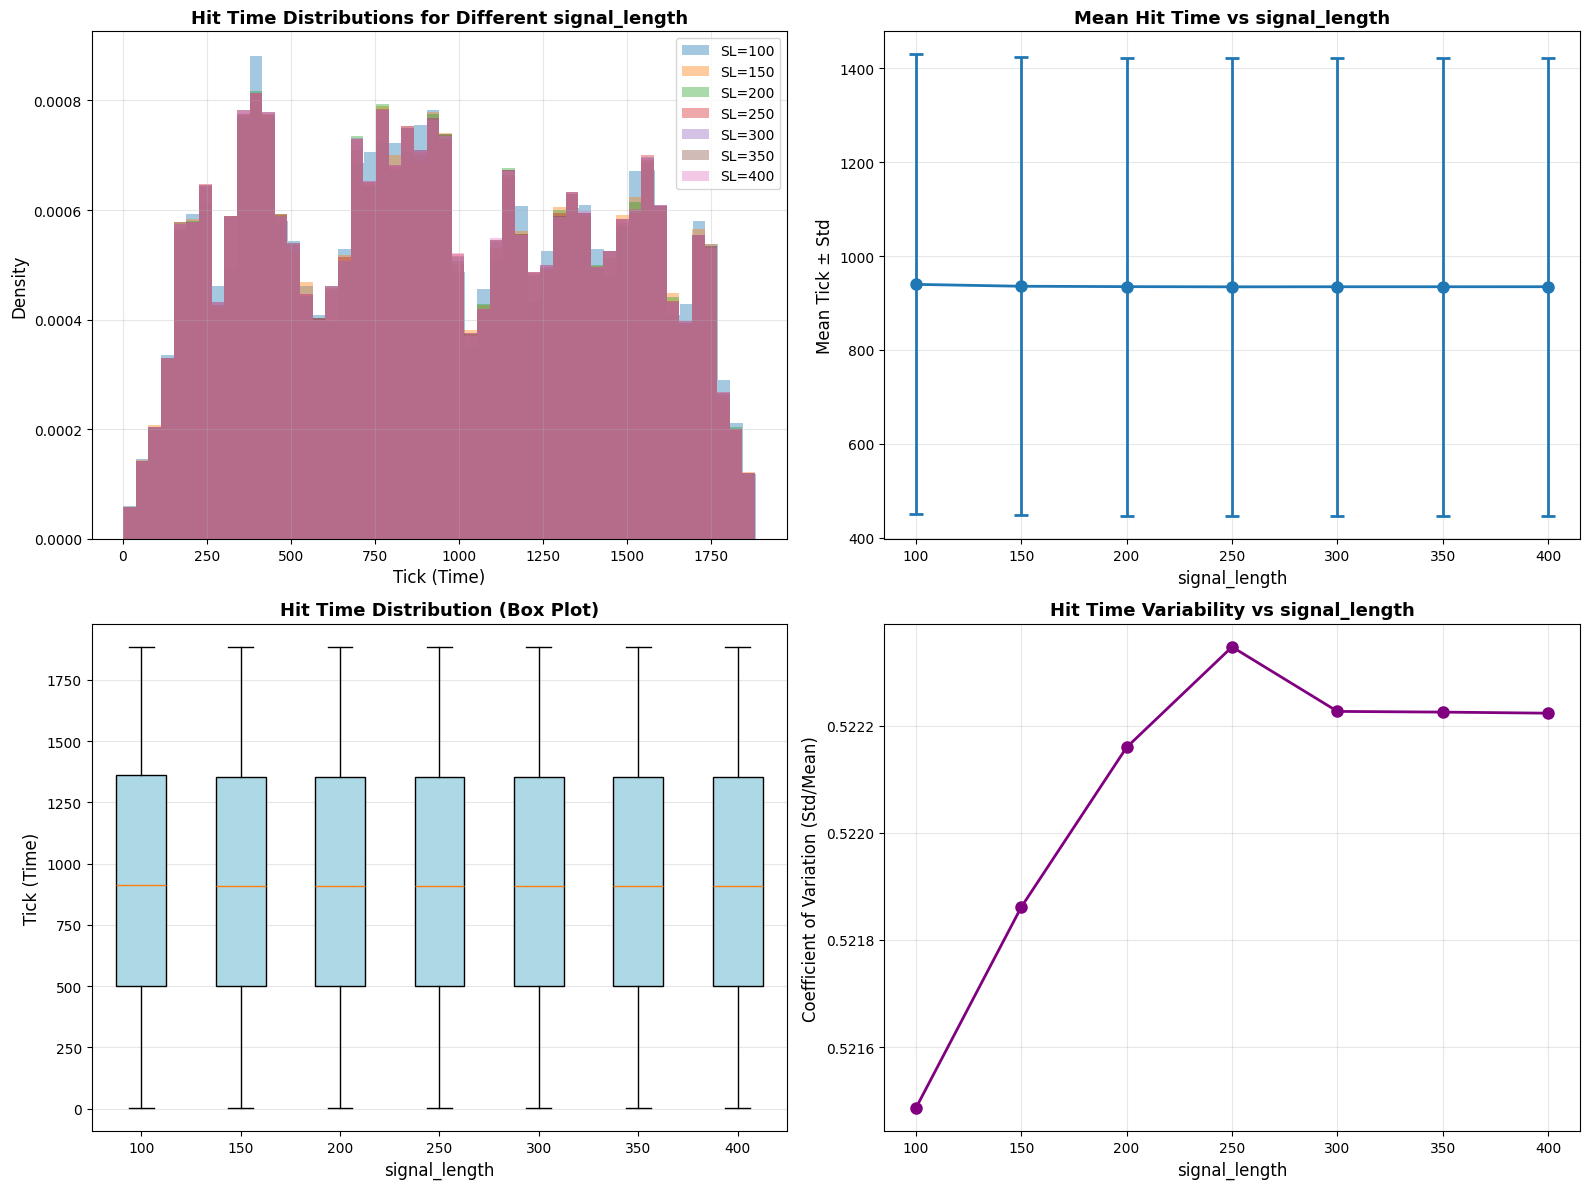

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tick distributions overlay
ax = axes[0, 0]
for sl in signal_lengths_to_compare:
    r = detailed_results[sl]
    ax.hist(r['ticks'], bins=50, alpha=0.4, label=f'SL={sl}', density=True)
ax.set_xlabel('Tick (Time)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Hit Time Distributions for Different signal_length', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Mean and std of ticks vs signal_length
ax = axes[0, 1]
mean_ticks = [float(detailed_results[sl]['ticks'].mean()) for sl in signal_lengths_to_compare]
std_ticks = [float(detailed_results[sl]['ticks'].std()) for sl in signal_lengths_to_compare]

ax.errorbar(signal_lengths_to_compare, mean_ticks, yerr=std_ticks, 
            fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2)
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Mean Tick ± Std', fontsize=12)
ax.set_title('Mean Hit Time vs signal_length', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Box plot of ticks
ax = axes[1, 0]
tick_data = [np.array(detailed_results[sl]['ticks']) for sl in signal_lengths_to_compare]
bp = ax.boxplot(tick_data, labels=signal_lengths_to_compare, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Tick (Time)', fontsize=12)
ax.set_title('Hit Time Distribution (Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. Coefficient of variation for ticks
ax = axes[1, 1]
cv_ticks = [float(detailed_results[sl]['ticks'].std() / detailed_results[sl]['ticks'].mean()) 
            for sl in signal_lengths_to_compare]
ax.plot(signal_lengths_to_compare, cv_ticks, 'o-', linewidth=2, markersize=8, color='purple')
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Coefficient of Variation (Std/Mean)', fontsize=12)
ax.set_title('Hit Time Variability vs signal_length', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualize Charge Distributions

/lscratch/pgranger/tmp/ipykernel_2677637/2248671609.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(charge_data, labels=signal_lengths_to_compare, patch_artist=True)


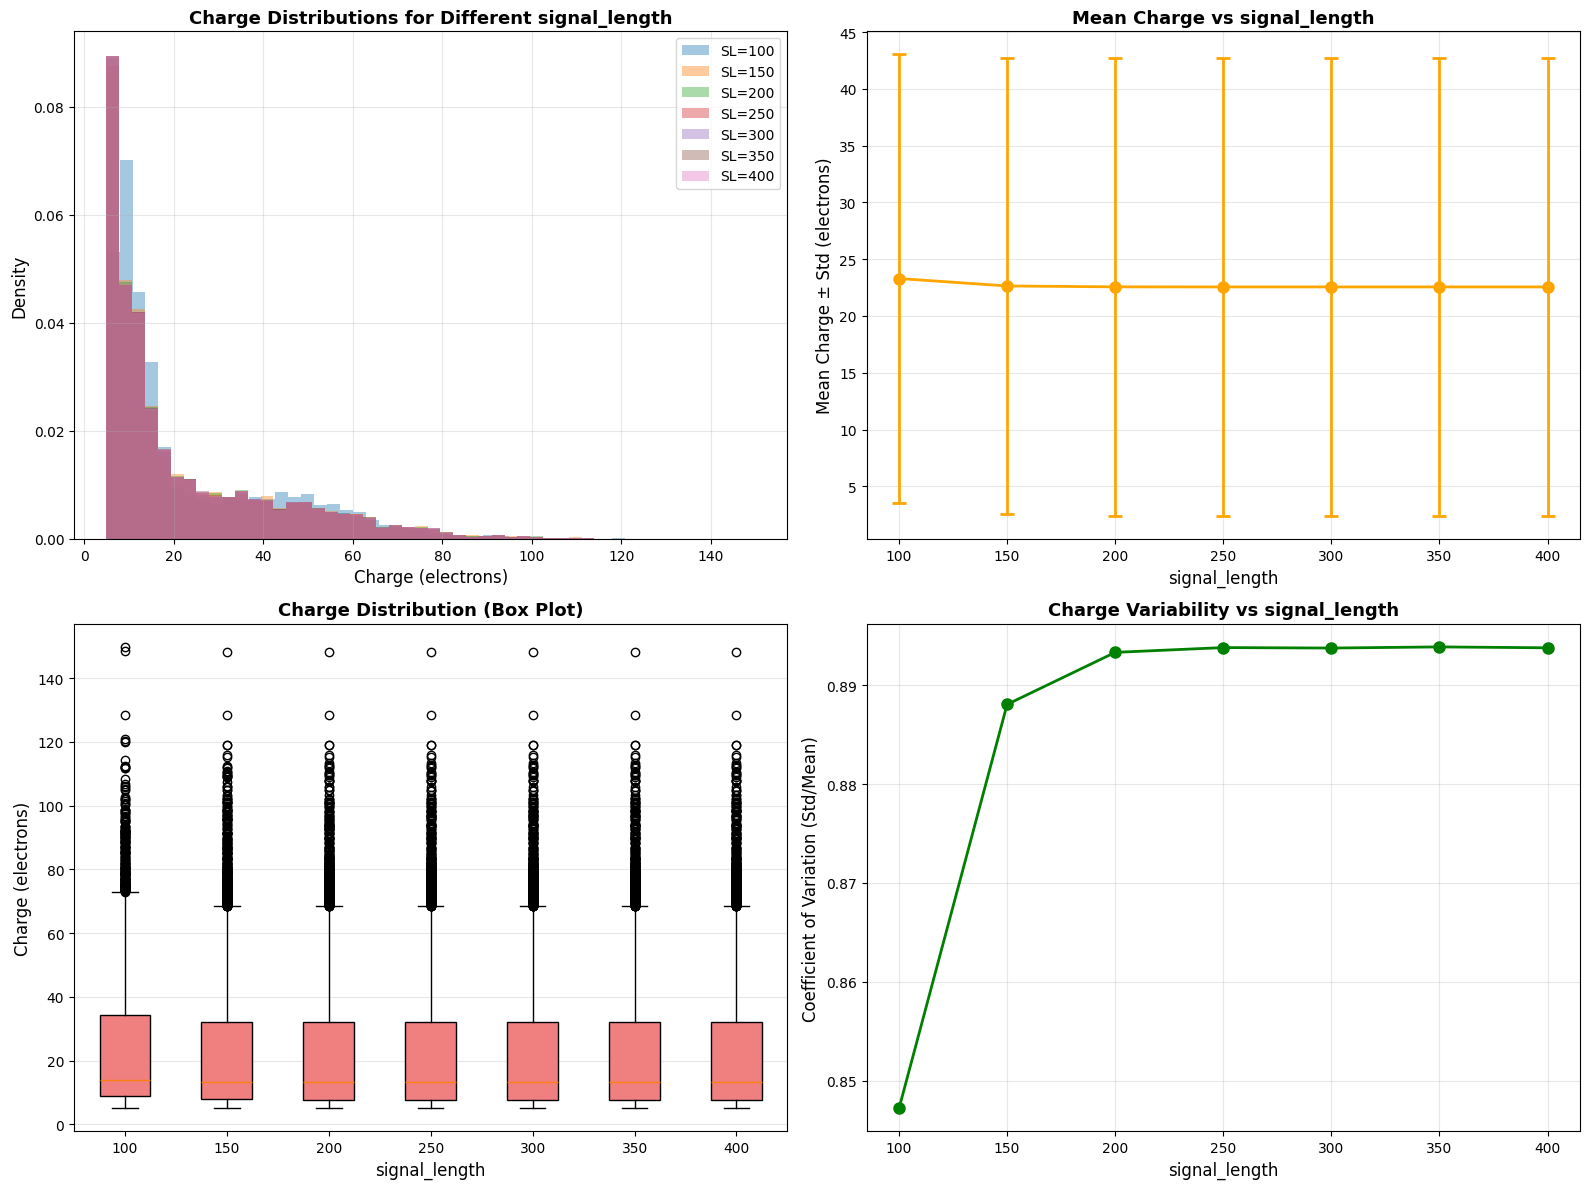

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Charge distributions overlay
ax = axes[0, 0]
for sl in signal_lengths_to_compare:
    r = detailed_results[sl]
    ax.hist(r['Q'], bins=50, alpha=0.4, label=f'SL={sl}', density=True)
ax.set_xlabel('Charge (electrons)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Charge Distributions for Different signal_length', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Mean and std of charge vs signal_length
ax = axes[0, 1]
mean_charge = [float(detailed_results[sl]['Q'].mean()) for sl in signal_lengths_to_compare]
std_charge = [float(detailed_results[sl]['Q'].std()) for sl in signal_lengths_to_compare]

ax.errorbar(signal_lengths_to_compare, mean_charge, yerr=std_charge, 
            fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2, color='orange')
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Mean Charge ± Std (electrons)', fontsize=12)
ax.set_title('Mean Charge vs signal_length', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Box plot of charges
ax = axes[1, 0]
charge_data = [np.array(detailed_results[sl]['Q']) for sl in signal_lengths_to_compare]
bp = ax.boxplot(charge_data, labels=signal_lengths_to_compare, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Charge (electrons)', fontsize=12)
ax.set_title('Charge Distribution (Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. Coefficient of variation for charge
ax = axes[1, 1]
cv_charge = [float(detailed_results[sl]['Q'].std() / detailed_results[sl]['Q'].mean()) 
             for sl in signal_lengths_to_compare]
ax.plot(signal_lengths_to_compare, cv_charge, 'o-', linewidth=2, markersize=8, color='green')
ax.set_xlabel('signal_length', fontsize=12)
ax.set_ylabel('Coefficient of Variation (Std/Mean)', fontsize=12)
ax.set_title('Charge Variability vs signal_length', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Relative Changes Compared to Baseline

In [13]:
# Use the nominal signal_length as baseline
baseline_sl = 400
baseline_results = detailed_results[baseline_sl]

print(f"Relative changes compared to baseline signal_length = {baseline_sl}")
print("=" * 100)
print(f"{'signal_length':<15} {'ΔN_hits (%)':<15} {'ΔMean_Tick (%)':<18} {'ΔStd_Tick (%)':<18} {'ΔMean_Q (%)':<15} {'ΔStd_Q (%)':<15}")
print("-" * 100)

for sl in signal_lengths_to_compare:
    if sl == baseline_sl:
        continue
    
    r = detailed_results[sl]
    
    delta_n_hits = (r['n_hits'] - baseline_results['n_hits']) / baseline_results['n_hits'] * 100
    delta_mean_tick = (float(r['ticks'].mean()) - float(baseline_results['ticks'].mean())) / float(baseline_results['ticks'].mean()) * 100
    delta_std_tick = (float(r['ticks'].std()) - float(baseline_results['ticks'].std())) / float(baseline_results['ticks'].std()) * 100
    delta_mean_q = (float(r['Q'].mean()) - float(baseline_results['Q'].mean())) / float(baseline_results['Q'].mean()) * 100
    delta_std_q = (float(r['Q'].std()) - float(baseline_results['Q'].std())) / float(baseline_results['Q'].std()) * 100
    
    print(f"{sl:<15} {delta_n_hits:<+15.3f} {delta_mean_tick:<+18.4f} {delta_std_tick:<+18.4f} "
          f"{delta_mean_q:<+15.4f} {delta_std_q:<+15.4f}")

Relative changes compared to baseline signal_length = 400
signal_length   ΔN_hits (%)     ΔMean_Tick (%)     ΔStd_Tick (%)      ΔMean_Q (%)     ΔStd_Q (%)     
----------------------------------------------------------------------------------------------------
100             -3.491          +0.5391            +0.3971            +3.2807         -2.1026        
150             -0.362          +0.1080            +0.0385            +0.3760         -0.2667        
200             +0.022          +0.0221            +0.0098            +0.0240         -0.0275        
250             +0.022          -0.0241            -0.0004            -0.0012         +0.0014        
300             +0.011          -0.0043            -0.0036            -0.0030         -0.0057        
350             +0.011          -0.0035            -0.0031            -0.0043         +0.0059        


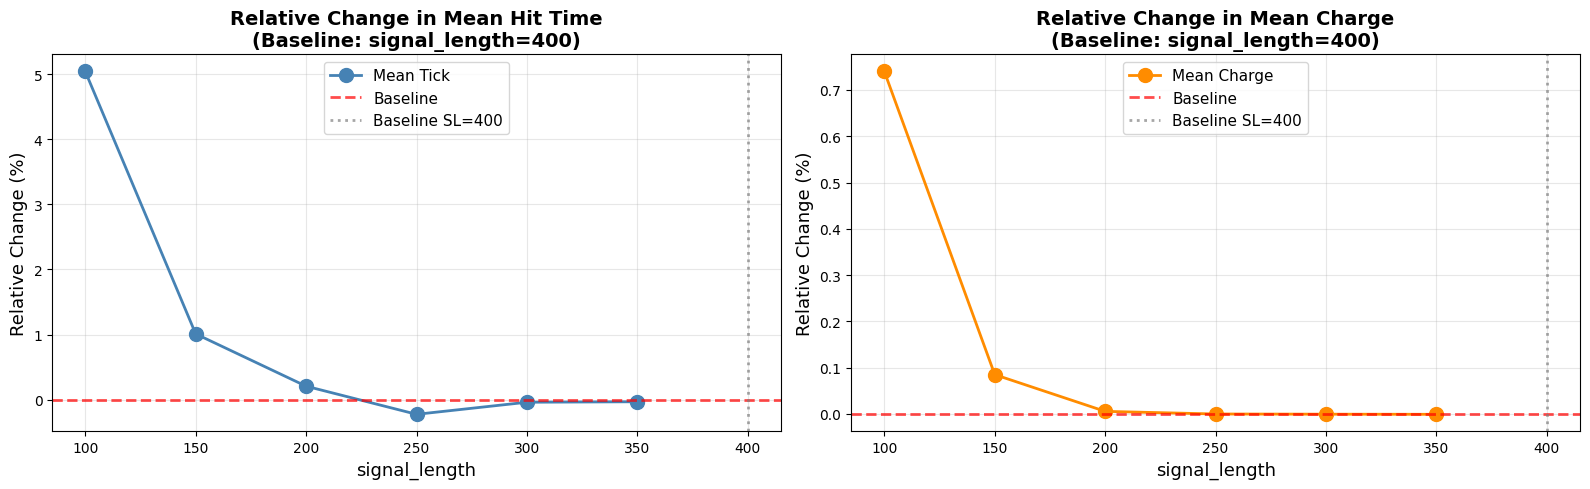

In [16]:
# Visualize relative changes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter out baseline for plotting relative changes
sl_compare = [sl for sl in signal_lengths_to_compare if sl != baseline_sl]

# Calculate relative changes - AVERAGING THE DIFFERENCES, not difference of averages
baseline_mean_tick = float(baseline_results['ticks'].mean())
baseline_mean_q = float(baseline_results['Q'].mean())

rel_mean_tick = [float(((detailed_results[sl]['ticks'] - baseline_mean_tick)).mean()) 
                 for sl in sl_compare]
rel_mean_q = [float(((detailed_results[sl]['Q'] - baseline_mean_q)).mean()) 
              for sl in sl_compare]

# Plot 1: Relative change in mean tick
ax = axes[0]
ax.plot(sl_compare, rel_mean_tick, 'o-', linewidth=2, markersize=10, color='steelblue', label='Mean Tick')
ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Baseline')
ax.axvline(baseline_sl, color='gray', linestyle=':', linewidth=2, alpha=0.7, label=f'Baseline SL={baseline_sl}')
ax.set_xlabel('signal_length', fontsize=13)
ax.set_ylabel('Relative Change (%)', fontsize=13)
ax.set_title(f'Relative Change in Mean Hit Time\n(Baseline: signal_length={baseline_sl})', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Relative change in mean charge
ax = axes[1]
ax.plot(sl_compare, rel_mean_q, 'o-', linewidth=2, markersize=10, color='darkorange', label='Mean Charge')
ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Baseline')
ax.axvline(baseline_sl, color='gray', linestyle=':', linewidth=2, alpha=0.7, label=f'Baseline SL={baseline_sl}')
ax.set_xlabel('signal_length', fontsize=13)
ax.set_ylabel('Relative Change (%)', fontsize=13)
ax.set_title(f'Relative Change in Mean Charge\n(Baseline: signal_length={baseline_sl})', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Joint Time-Charge Scatter Plots

Visualize the relationship between hit time and charge for different signal_length values.

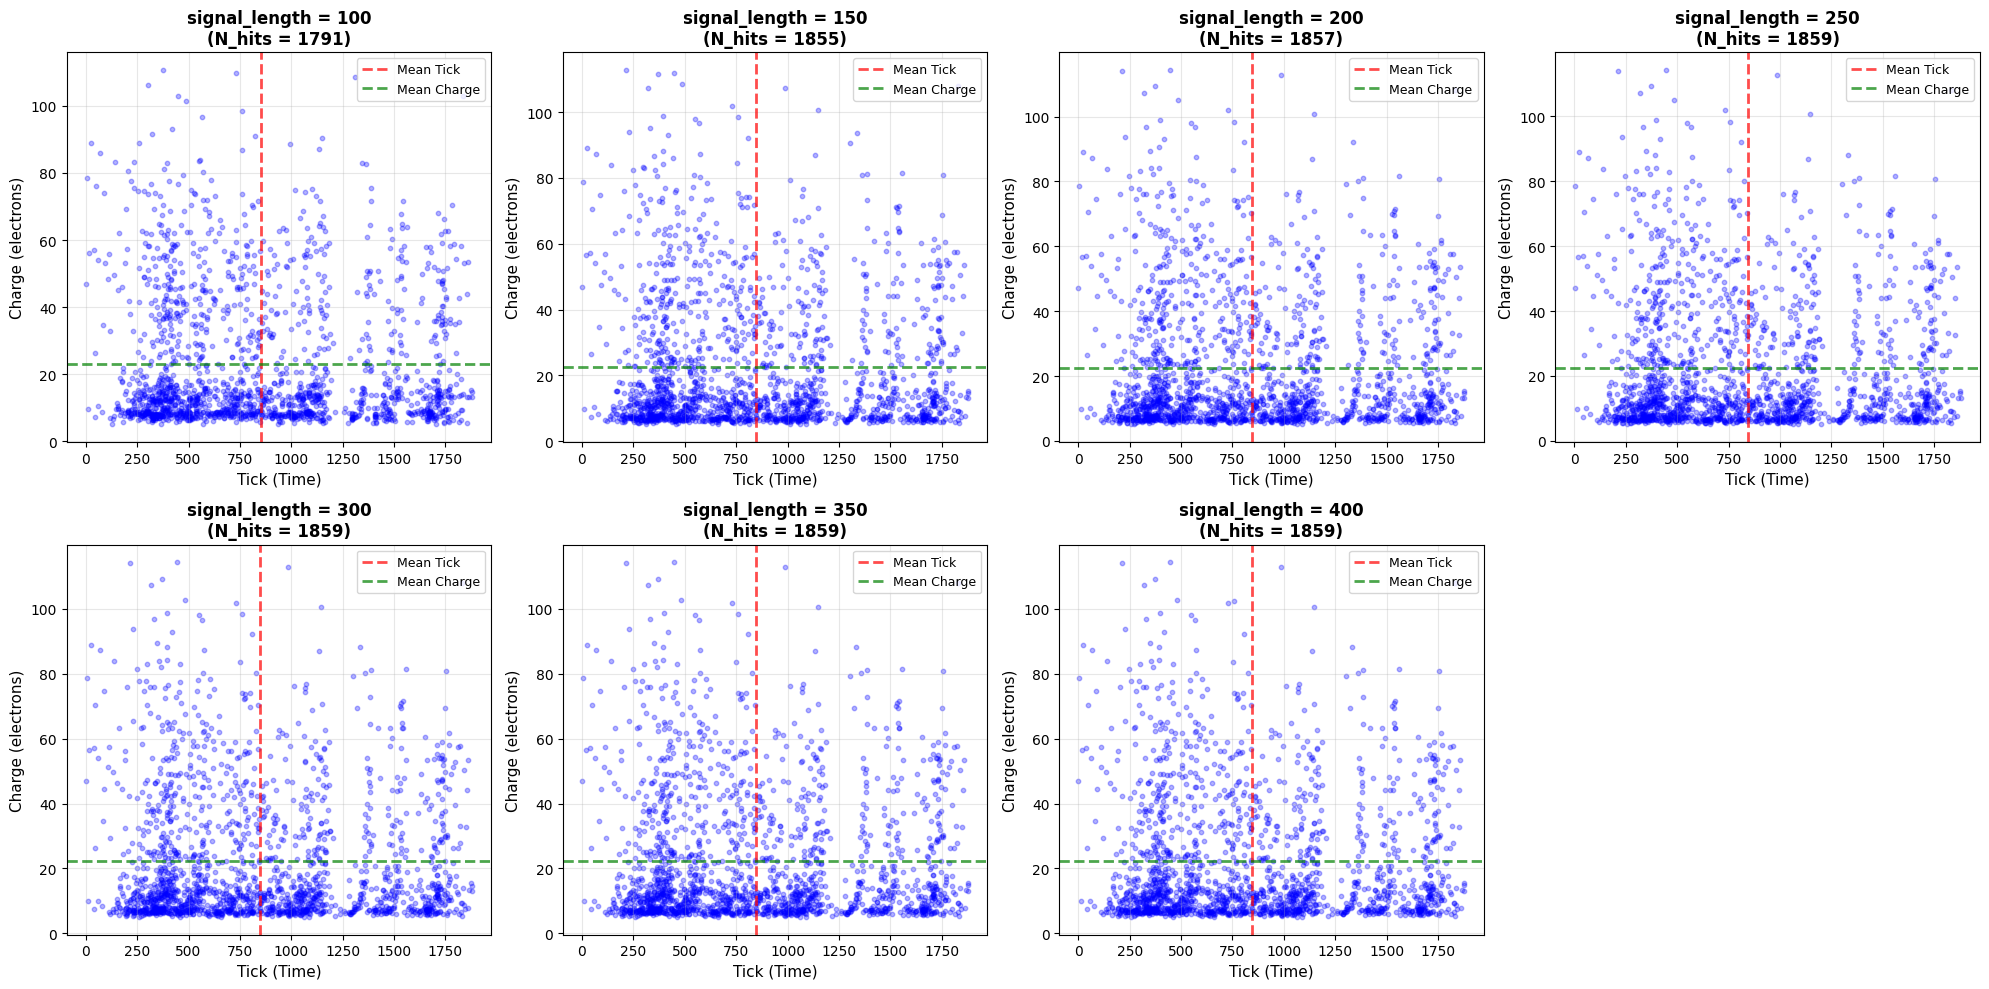

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sl in enumerate(signal_lengths_to_compare):
    ax = axes[idx]
    r = detailed_results[sl]
    
    # Create 2D histogram / scatter
    ax.scatter(r['ticks'], r['Q'], alpha=0.3, s=10, c='blue')
    
    ax.set_xlabel('Tick (Time)', fontsize=11)
    ax.set_ylabel('Charge (electrons)', fontsize=11)
    ax.set_title(f'signal_length = {sl}\n(N_hits = {r["n_hits"]})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add mean lines
    ax.axvline(float(r['ticks'].mean()), color='red', linestyle='--', alpha=0.7, linewidth=2, label='Mean Tick')
    ax.axhline(float(r['Q'].mean()), color='green', linestyle='--', alpha=0.7, linewidth=2, label='Mean Charge')
    ax.legend(fontsize=9)

# Hide extra subplot if odd number
if len(signal_lengths_to_compare) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Summary: Impact Assessment

Based on the visualizations above, you can assess:

1. **Hit Time Variations**: Check if mean tick values and their distributions change significantly across different `signal_length` values
2. **Charge Variations**: Examine whether charge distributions and mean values are stable
3. **Relative Changes**: Small percentage changes (< 1%) suggest minimal impact
4. **Hit Count Stability**: Number of detected hits should remain relatively constant if the parameter has minimal effect

**Key Metrics to Consider:**
- If relative changes in mean tick and charge are < 0.1%, the impact is negligible
- If coefficient of variation remains stable, the variability is consistent
- If the time-charge scatter plots show similar patterns, the parameter's effect is minimal